In [2]:
import pandas as pd
import sqlite3

## создать подлючение к БД

In [3]:
try:
  conn = sqlite3.connect('data/checking-logs.sqlite')
  print('Подключение состоялось')
except sqlite3.Error as error:
  print('Подключение не состоялось:', error)

Подключение состоялось


## запустите запрос, который получает дату и время из таблицы просмотров страниц, выбирая только пользователей, а не администраторов

In [4]:
query = '''
SELECT *
FROM pageviews
WHERE uid LIKE 'user_%'
'''
df = pd.io.sql.read_sql(query, conn, parse_dates=['datetime'])
df

,index,uid,datetime
0,12,user_30,2020-04-17 22:46:26.785035
1,14,user_14,2020-04-18 10:53:52.623447
2,15,user_17,2020-04-18 10:56:55.833899
3,16,user_14,2020-04-18 10:57:37.331258
4,18,user_17,2020-04-18 12:05:48.200144
...,...,...,...
982,1073,user_28,2020-05-21 18:45:20.441142
983,1074,user_19,2020-05-21 23:03:06.457819
984,1075,user_25,2020-05-21 23:23:49.995349
985,1078,user_5,2020-05-22 11:30:18.368990


## используя Pandas, создайте новый фрейм данных, в котором посещения подсчитываются и группируются по дате.

In [5]:
df_view = df.groupby(by=df['datetime'].dt.date).agg({'uid': ['count']})
df_view = df_view.reset_index()
df_view.columns = ['date', 'view']
df_view

,date,view
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


## используя метод Pandas .plot(), создайте график
- размер шрифта должен быть 8
- размер фигуры (15,8)
- график должен иметь заголовок «Views per day»
- обратите внимание на вращение xticks на графике ниже

<Axes: title={'center': 'Views per day'}, xlabel='date'>

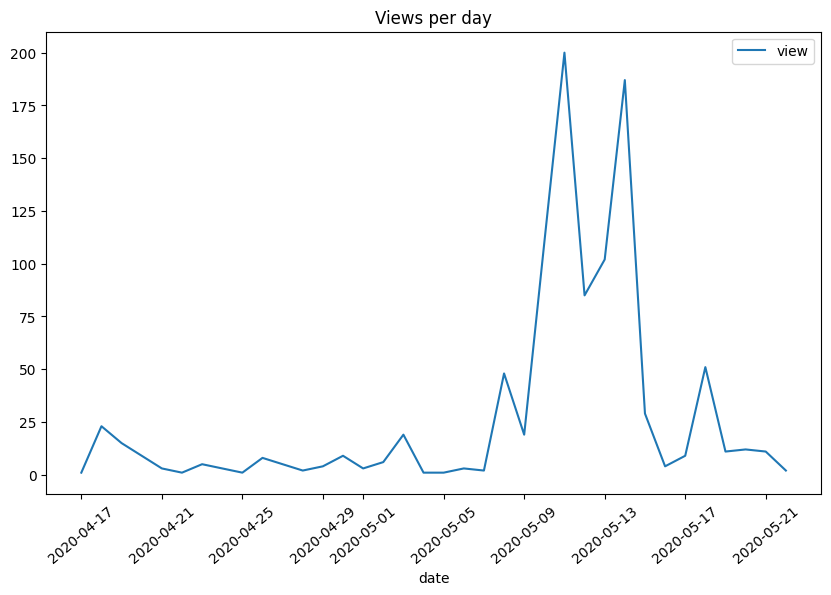

In [7]:
df_view.plot(x='date', y='view', figsize=(10, 6), title='Views per day', rot=40, fontsize=10)

In [8]:
conn.close()
